### Pós-graduação em Ciência de Dados e Machine Learning

#### Disciplina: **Introdução a Redes Neurais**

#### Projeto Final para disciplina Introdução a Redes Neurais

<BR>
    

#### Nome dos integrantes:  
#### RA: 
#### RA: 
#### RA: 
#### RA: 


# Classificação de Pneumonia em Raios-X Torácicos

**Objetivo**: Desenvolver um modelo de Deep Learning para classificar imagens de raios-X torácicos em "Normal" ou "Pneumonia".

**Dataset**: Chest X-Ray Images (Pneumonia) do Kaggle, com a seguinte estrutura:
- `chest_xray/train/`
  - `NORMAL/`
  - `PNEUMONIA/`
- `chest_xray/test/`
  - `NORMAL/`
  - `PNEUMONIA/`
- `chest_xray/val/`
  - `NORMAL/`
  - `PNEUMONIA/`

**Base Teórica**: Inspirado no artigo CheXNet (Rajpurkar et al., 2017) que utilizou DenseNet-121 para alcançar desempenho de nível radiologista.


In [ ]:
# Importação de bibliotecas
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import cv2

import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd

In [2]:
# Verificando a estrutura dos diretórios
base_dir = 'C:/Users/MMARAGAO/Desktop/trabalho/chest_xray/chest_xray'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'val')
test_dir = os.path.join(base_dir, 'test')

print("Diretório de treino:", os.listdir(train_dir))
print("Diretório de validação:", os.listdir(val_dir))
print("Diretório de teste:", os.listdir(test_dir))

Diretório de treino: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Diretório de validação: ['.DS_Store', 'NORMAL', 'PNEUMONIA']
Diretório de teste: ['.DS_Store', 'NORMAL', 'PNEUMONIA']


In [3]:
# Análise exploratória - Contagem de imagens em cada conjunto
def count_images(directory):
    normal = len(os.listdir(os.path.join(directory, 'NORMAL')))
    pneumonia = len(os.listdir(os.path.join(directory, 'PNEUMONIA')))
    return normal, pneumonia

train_normal, train_pneumonia = count_images(train_dir)
val_normal, val_pneumonia = count_images(val_dir)
test_normal, test_pneumonia = count_images(test_dir)

print(f"Treino - Normal: {train_normal}, Pneumonia: {train_pneumonia}")
print(f"Validação - Normal: {val_normal}, Pneumonia: {val_pneumonia}")
print(f"Teste - Normal: {test_normal}, Pneumonia: {test_pneumonia}")

Treino - Normal: 1342, Pneumonia: 3876
Validação - Normal: 9, Pneumonia: 9
Teste - Normal: 234, Pneumonia: 390


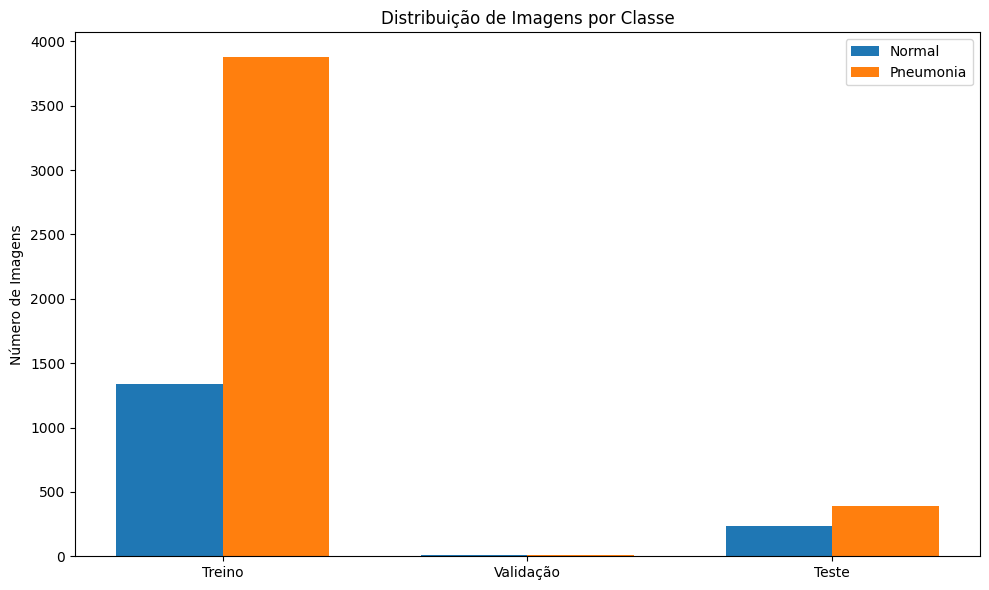

In [4]:
# Criando um gráfico de barras
labels = ['Treino', 'Validação', 'Teste']
normal_counts = [train_normal, val_normal, test_normal]
pneumonia_counts = [train_pneumonia, val_pneumonia, test_pneumonia]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, normal_counts, width, label='Normal')
rects2 = ax.bar(x + width/2, pneumonia_counts, width, label='Pneumonia')

ax.set_ylabel('Número de Imagens')
ax.set_title('Distribuição de Imagens por Classe')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

fig.tight_layout()
plt.show()

In [5]:
# Pré-processamento e aumento de dados
img_size = 224
batch_size = 32

In [6]:
# Data augmentation para o conjunto de treino
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    fill_mode='nearest'
)

In [7]:
# Para validação e teste, apenas normalização
val_test_datagen = ImageDataGenerator(rescale=1./255)

In [8]:
# Geradores de dados
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=True
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(img_size, img_size),
    batch_size=batch_size,
    class_mode='binary',
    shuffle=False
)


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.


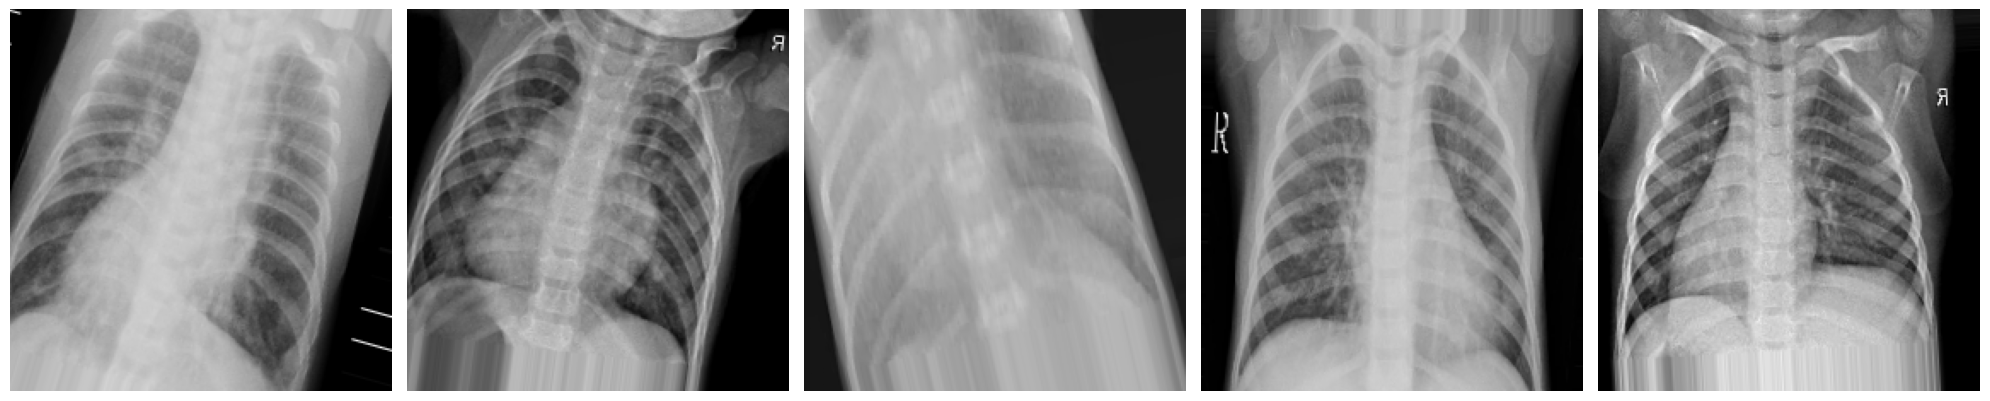

In [9]:
# Visualização de algumas imagens do dataset
def plot_images(images_arr):
    fig, axes = plt.subplots(1, 5, figsize=(20, 20))
    axes = axes.flatten()
    for img, ax in zip(images_arr, axes):
        ax.imshow(img)
        ax.axis('off')
    plt.tight_layout()
    plt.show()

sample_images, _ = next(train_generator)
plot_images(sample_images[:5])

In [10]:
# Callbacks
early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [11]:
def build_model():
    base_model = DenseNet121(
        include_top=False,
        weights='imagenet',
        input_shape=(224, 224, 3),
        pooling=None
    )
    base_model.trainable = False

    inputs = layers.Input(shape=(224, 224, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    
    model = models.Model(inputs, outputs)
    
    model.compile(
        optimizer=Adam(learning_rate=0.0001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC()]
    )
    return model

# 3. Construir o modelo
model = build_model()

# 4. Verificar a arquitetura
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,300,161 (27.85 MB)

 Trainable params: 262,657 (1.00 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

In [12]:
# Treinamento do modelo
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // batch_size,
    epochs=20,
    validation_data=val_generator,
    validation_steps=val_generator.samples // batch_size,
    callbacks=[early_stopping, reduce_lr]
)

c:\Users\MMARAGAO\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 169s 1000ms/step - accuracy: 0.7559 - auc: 0.7408 - loss: 0.5101 - val_accuracy: 0.7500 - val_auc: 0.8750 - val_loss: 0.4776 - learning_rate: 1.0000e-04
Epoch 2/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 665ms/step - accuracy: 0.9077 - auc: 0.9532 - loss: 0.2428 - val_accuracy: 0.8125 - val_auc: 0.9219 - val_loss: 0.4329 - learning_rate: 1.0000e-04
Epoch 3/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 678ms/step - accuracy: 0.9170 - auc: 0.9653 - loss: 0.2048 - val_accuracy: 0.8750 - val_auc: 0.9375 - val_loss: 0.4191 - learning_rate: 1.0000e-04
Epoch 4/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 676ms/step - accuracy: 0.9285 - auc: 0.9706 - loss: 0.1930 - val_accuracy: 0.8750 - val_auc: 0.9375 - val_loss: 0.4130 - learning_rate: 1.0000e-04
Epoch 5/20
163/163 ━━━━━━━━━━━━━━━━━━━━ 111s 680ms/step - accuracy: 0.9366 - auc: 0.9785 - loss: 0.1626 - val_accuracy: 0.8750 - val_auc: 0.9375 - val_loss: 0.4324 - learning_rate: 1.0000e-04
Epoch 6/20
163/163 ━━━━━━━━━━━━━━━━━━━━

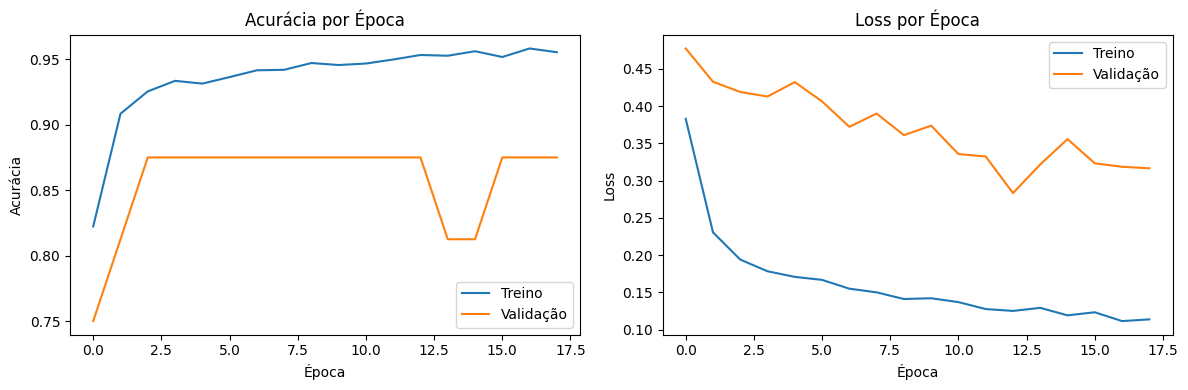

In [13]:
# Visualização do histórico de treinamento
def plot_training_history(history):
    plt.figure(figsize=(12, 4))
    
    # Gráfico de acurácia
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], label='Treino')
    plt.plot(history.history['val_accuracy'], label='Validação')
    plt.title('Acurácia por Época')
    plt.xlabel('Época')
    plt.ylabel('Acurácia')
    plt.legend()
    
    # Gráfico de loss
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Treino')
    plt.plot(history.history['val_loss'], label='Validação')
    plt.title('Loss por Época')
    plt.xlabel('Época')
    plt.ylabel('Loss')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

plot_training_history(history)

In [14]:
# Avaliação no conjunto de teste
test_loss, test_acc, test_auc = model.evaluate(test_generator)
print(f'\nAcurácia no teste: {test_acc:.2%}')
print(f'AUC no teste: {test_auc:.2%}')

20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 752ms/step - accuracy: 0.8067 - auc: 0.6309 - loss: 0.4756

Acurácia no teste: 87.18%
AUC no teste: 94.86%


In [1]:
# Matriz de confusão e relatório de classificação
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Previsões no conjunto de teste
test_generator.reset()
y_pred = model.predict(test_generator)
y_pred = (y_pred > 0.5).astype(int)
y_true = test_generator.classes

# Matriz de confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Normal', 'Pneumonia'], 
            yticklabels=['Normal', 'Pneumonia'])
plt.ylabel('Verdadeiro')
plt.xlabel('Predito')
plt.title('Matriz de Confusão')
plt.show()

# Relatório de classificação
print(classification_report(y_true, y_pred, target_names=['Normal', 'Pneumonia']))

NameError: name 'test_generator' is not defined

In [ ]:


def make_gradcam_heatmap(img_array, model, last_conv_layer_name, pred_index=None):
    """
    Gera o heatmap Grad-CAM para uma imagem e um modelo dado.

    Args:
        img_array (np.array): imagem já preprocessada e expandida (shape (1, height, width, channels))
        model (tf.keras.Model): modelo treinado
        last_conv_layer_name (str): nome da última camada convolucional
        pred_index (int, optional): índice da classe para a qual gerar o Grad-CAM

    Returns:
        heatmap (np.array): mapa de calor normalizado
    """
    # Criar um modelo que mapeia inputs -> ativações da última camada convolucional + saída
    grad_model = tf.keras.models.Model(
        [model.inputs], 
        [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # Usar o GradientTape para calcular os gradientes
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        output_class = predictions[:, pred_index]

    # Gradiente da saída em relação às ativações da última camada convolucional
    grads = tape.gradient(output_class, conv_outputs)

    # Média dos gradientes em cada canal
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    # Multiplicar os canais da camada convolucional pelos gradientes
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # Normalizar entre 0 e 1
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    return heatmap.numpy()

def display_gradcam(img_path, heatmap, alpha=0.4, cmap='jet'):
    """
    Exibe a imagem original com o Grad-CAM sobreposto.

    Args:
        img_path (str): caminho da imagem original
        heatmap (np.array): heatmap gerado pela função make_gradcam_heatmap
        alpha (float, optional): intensidade do heatmap sobre a imagem
        cmap (str, optional): colormap para o heatmap
    """
    # Carregar a imagem original
    img = tf.keras.preprocessing.image.load_img(img_path)
    img = tf.keras.preprocessing.image.img_to_array(img)

    # Redimensionar o heatmap para o tamanho da imagem
    heatmap = cv2.resize(heatmap, (img.shape[1], img.shape[0]))

    # Aplicar o colormap no heatmap
    heatmap_colored = cv2.applyColorMap(np.uint8(255 * heatmap), cv2.COLORMAP_JET)

    # Converter BGR (OpenCV padrão) para RGB
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)

    # Superpor o heatmap à imagem original
    superimposed_img = heatmap_colored * alpha + img
    superimposed_img = np.clip(superimposed_img / 255.0, 0, 1)

    # Exibir
    plt.figure(figsize=(8, 8))
    plt.imshow(superimposed_img)
    plt.axis('off')
    plt.title('Grad-CAM')
    plt.show()
